# 📊 Data Visualization — Tips Dataset

**Dataset chosen:** Tips Dataset

The Tips dataset contains records of customer bills at a restaurant, including the tip amount,
the total bill, the day and time of the visit, party size, smoker status, and gender of the
bill-payer. It has a good mix of numeric and categorical variables, which makes it well suited
to demonstrate every chart type required for this task.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global style settings for readability
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12

print("Libraries imported successfully.")


Libraries imported successfully.


## Load the Dataset

In [2]:
# Load the built-in Tips dataset from seaborn
df = sns.load_dataset("tips")

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
# Quick overview of the data
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
df.describe(include='all')


,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


## Line Plot — Average Total Bill by Party Size

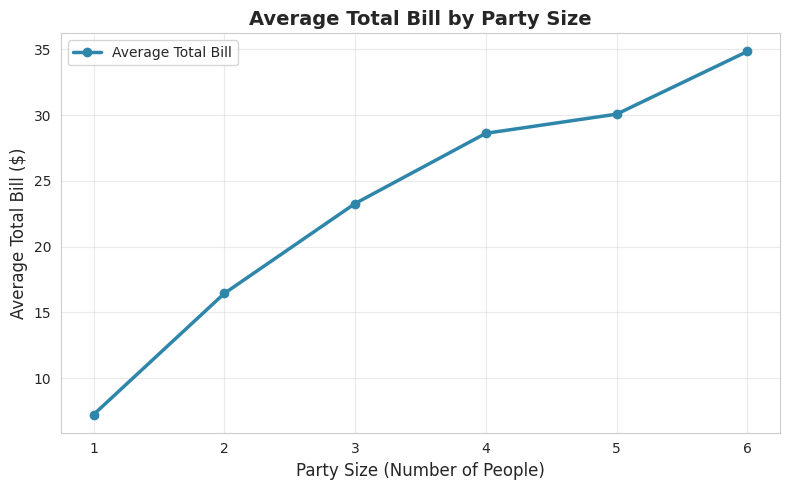

In [5]:
# Line Plot: Average total bill as party size increases
avg_bill_by_size = df.groupby('size')['total_bill'].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(avg_bill_by_size['size'], avg_bill_by_size['total_bill'],
         marker='o', linewidth=2.5, color='#2E86AB', label='Average Total Bill')

plt.title('Average Total Bill by Party Size', fontsize=14, fontweight='bold')
plt.xlabel('Party Size (Number of People)')
plt.ylabel('Average Total Bill ($)')
plt.xticks(avg_bill_by_size['size'])
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


**Analysis:**
- **Why this chart?** A line plot is ideal here because `size` (number of people at the table) is an
  ordered, continuous-like numeric variable, and we want to see the *trend* in average spending as
  that value increases.
- **What it represents:** Each point shows the average total bill for a specific party size, connected
  in order to reveal the overall trend.
- **Insights:** Average total bill generally rises as party size increases, which makes intuitive sense
  since larger groups tend to order more food. However, the increase is not perfectly linear — some
  group sizes (e.g. very large parties) have fewer data points, so the average can fluctuate more.


## Bar Chart — Average Tip Amount by Day of the Week

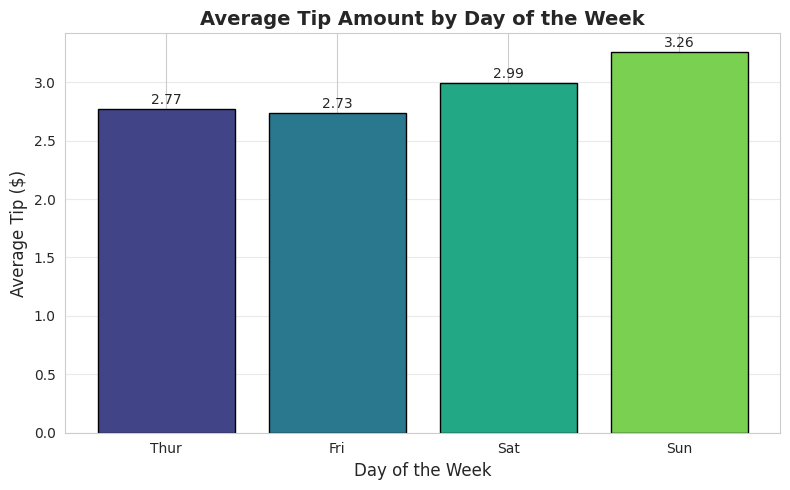

In [6]:
# Bar Chart: Average tip per day
avg_tip_by_day = df.groupby('day', observed=True)['tip'].mean().reindex(['Thur','Fri','Sat','Sun'])

plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", len(avg_tip_by_day))
bars = plt.bar(avg_tip_by_day.index, avg_tip_by_day.values, color=colors, edgecolor='black')

plt.title('Average Tip Amount by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Average Tip ($)')
plt.grid(axis='y', alpha=0.4)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


**Analysis:**
- **Why this chart?** A bar chart is the natural choice for comparing a single numeric value
  (average tip) across discrete categories (days of the week).
- **What it represents:** The height of each bar shows the average tip customers left on that day.
- **Insights:** Tips tend to be highest on **Sunday**, suggesting weekend diners may be more generous
  or order more expensive meals, while weekday (Thursday/Friday) tips are comparatively lower.


## Histogram — Distribution of Total Bill Amounts

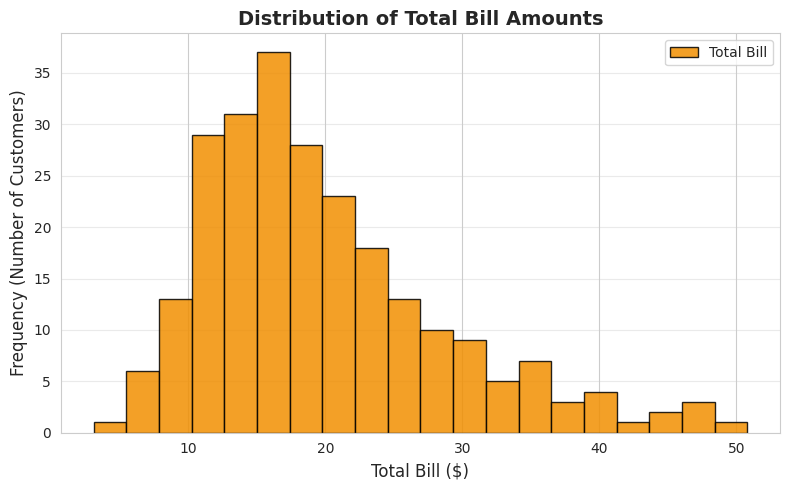

In [7]:
# Histogram: Distribution of total bill
plt.figure(figsize=(8, 5))
plt.hist(df['total_bill'], bins=20, color='#F18F01', edgecolor='black', alpha=0.85, label='Total Bill')

plt.title('Distribution of Total Bill Amounts', fontsize=14, fontweight='bold')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency (Number of Customers)')
plt.grid(axis='y', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


**Analysis:**
- **Why this chart?** A histogram is the best way to visualize the *distribution* and *spread* of a
  single continuous numeric variable like total bill.
- **What it represents:** Each bar shows how many customers had a total bill within that dollar range.
- **Insights:** The distribution is **right-skewed** — most bills fall between \$10–\$20, with a long
  tail of larger bills extending toward \$40–\$50. This tells us most customers order moderately priced
  meals, while high-spending customers are relatively rare.


## Scatter Plot — Total Bill vs. Tip Amount

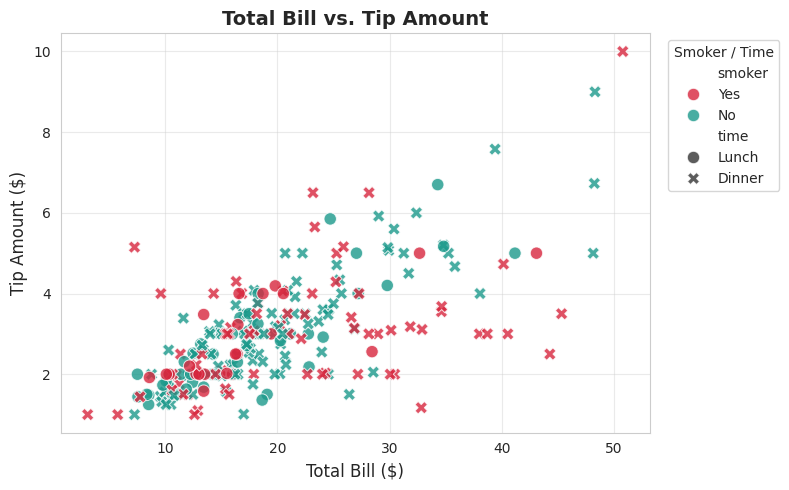

In [8]:
# Scatter Plot: Relationship between total bill and tip, colored by smoker status
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='smoker', style='time',
                 palette={'Yes': '#D7263D', 'No': '#1B998B'}, s=80, alpha=0.8)

plt.title('Total Bill vs. Tip Amount', fontsize=14, fontweight='bold')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip Amount ($)')
plt.grid(True, alpha=0.4)
plt.legend(title='Smoker / Time', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Analysis:**
- **Why this chart?** A scatter plot is the standard way to examine the relationship (correlation)
  between two continuous numeric variables — here, total bill and tip.
- **What it represents:** Each point is one customer visit; its position shows their total bill (x-axis)
  and how much they tipped (y-axis). Color and marker style break the points down by smoker status and
  meal time.
- **Insights:** There is a clear **positive correlation** — larger bills tend to come with larger tips.
  Smokers and non-smokers follow a similar overall trend, though a few smoker data points show more
  variable tipping behavior (some tipping very little relative to their bill).


## Box Plot — Total Bill Distribution by Day and Time

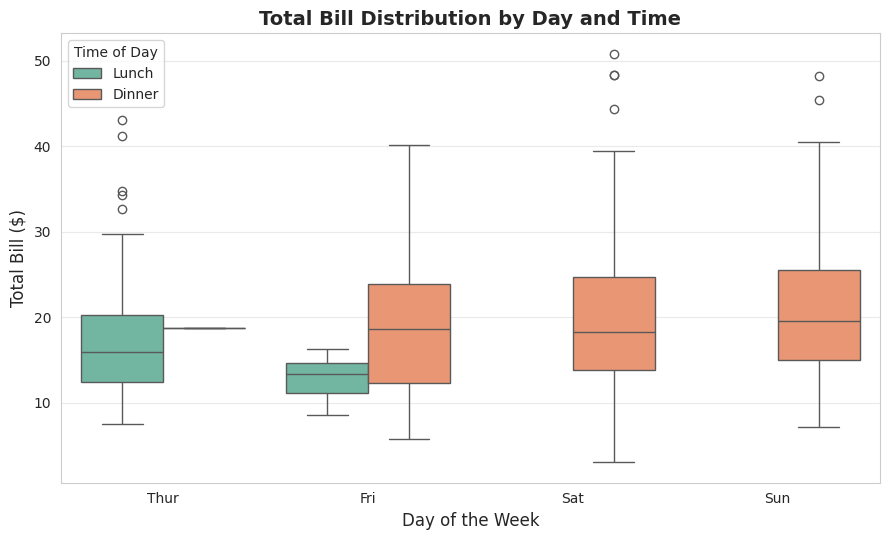

In [9]:
# Box Plot: Total bill spread across days, split by time (Lunch/Dinner)
plt.figure(figsize=(9, 5.5))
sns.boxplot(data=df, x='day', y='total_bill', hue='time', order=['Thur','Fri','Sat','Sun'],
            palette='Set2')

plt.title('Total Bill Distribution by Day and Time', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Total Bill ($)')
plt.grid(axis='y', alpha=0.4)
plt.legend(title='Time of Day')
plt.tight_layout()
plt.show()


**Analysis:**
- **Why this chart?** A box plot is ideal for comparing the spread, median, and outliers of a numeric
  variable (total bill) across multiple categorical groups (day and time) at once.
- **What it represents:** Each box shows the median (middle line), interquartile range (box), and
  outliers (points beyond the whiskers) of total bill for a given day/time combination.
- **Insights:** **Dinner bills** tend to be higher and more variable than **lunch bills** across most
  days. Saturday and Sunday (dinner-only in this dataset) show a wider spread and a few high outliers,
  indicating some very large weekend dinner parties.


## Count Plot — Number of Customers by Day

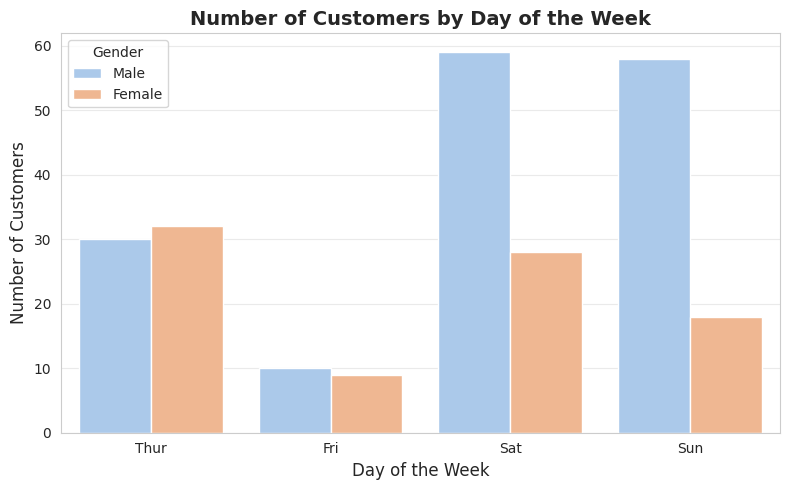

In [10]:
# Count Plot: Number of visits recorded per day, split by gender
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='day', hue='sex', order=['Thur','Fri','Sat','Sun'], palette='pastel')

plt.title('Number of Customers by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.4)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


**Analysis:**
- **Why this chart?** A count plot is the right tool for showing the frequency of observations in each
  category — here, how many records exist for each day, broken down by gender.
- **What it represents:** Bar height shows how many customer visits were recorded for each day, with
  color splitting each bar into male and female bill-payers.
- **Insights:** **Saturday** has the highest number of recorded visits, followed by Sunday, meaning the
  restaurant is busiest on weekends. Male customers pay the bill more often than female customers across
  every day in this dataset.


## Pair Plot — Relationships Between All Numeric Variables

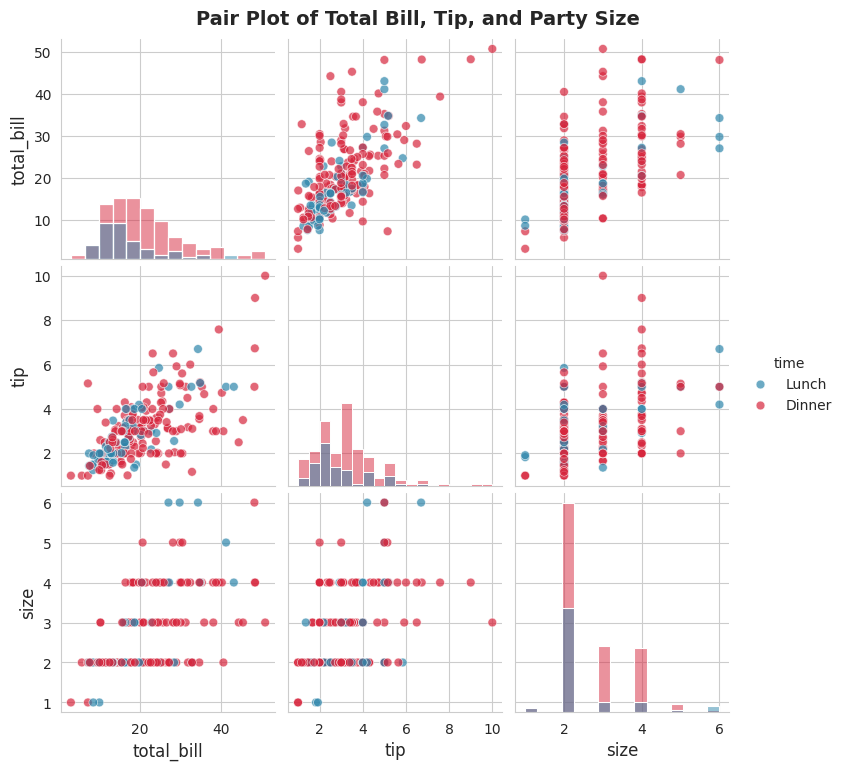

In [11]:
# Pair Plot: Explore relationships between all numeric variables at once
pair_grid = sns.pairplot(df, vars=['total_bill', 'tip', 'size'], hue='time',
                          palette={'Lunch': '#2E86AB', 'Dinner': '#D7263D'},
                          diag_kind='hist', plot_kws={'alpha': 0.7, 's': 40})

pair_grid.fig.suptitle('Pair Plot of Total Bill, Tip, and Party Size', y=1.02,
                        fontsize=14, fontweight='bold')
plt.show()


**Analysis:**
- **Why this chart?** A pair plot gives a quick, comprehensive overview of pairwise relationships
  between *all* numeric variables at once, plus their individual distributions on the diagonal — much
  faster than building separate scatter plots for every pair.
- **What it represents:** Off-diagonal plots show scatter relationships between pairs of variables
  (total bill, tip, size), colored by meal time; diagonal plots show each variable's individual
  distribution.
- **Insights:** `total_bill` and `tip` show the strongest positive relationship, confirming the earlier
  scatter plot finding. `size` also correlates positively with `total_bill` (larger groups spend more).
  Dinner visits generally involve higher bills and tips than lunch visits, visible across nearly every
  panel.


## Overall Conclusion

Across all six required charts and the bonus pair plot, a consistent story emerges from the Tips
dataset:

- **Spending scales with group size and meal time** — bigger parties and dinner service both drive up
  total bill amounts.
- **Tipping behavior tracks total bill** — the more a table spends, the more they tend to tip, though
  with some variability among smokers.
- **Weekends (Saturday & Sunday) are the busiest and highest-spending days**, both in customer count and
  average tip amount.
- **Most customers are moderate spenders** (right-skewed bill distribution), with a smaller number of
  high-spending outliers, mostly on weekend dinners.

These insights could help a restaurant plan staffing (more staff on weekend dinners), and understand
tipping patterns for service quality analysis.
